In [175]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("system_logins.csv")

df.head()

,timestamp,user_id,ip_address,country,success,os
0,2024-04-20 08:15:00,john,192.168.1.10,Uganda,True,Windows
1,2024-04-20 08:17:10,mary,192.168.1.11,Kenya,False,Linux
2,2024-04-20 08:20:00,john,192.168.1.10,Uganda,False,Windows
3,2024-04-20 08:25:00,peter,10.0.0.5,Tanzania,True,MacOS
4,2024-04-20 08:30:00,mary,192.168.1.11,Kenya,False,Linux


In [176]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   timestamp   6 non-null      str  
 1   user_id     6 non-null      str  
 2   ip_address  6 non-null      str  
 3   country     6 non-null      str  
 4   success     6 non-null      bool 
 5   os          6 non-null      str  
dtypes: bool(1), str(5)
memory usage: 378.0 bytes


In [177]:
df.isnull().sum()

timestamp     0
user_id       0
ip_address    0
country       0
success       0
os            0
dtype: int64

In [178]:
df = df.fillna("Unknown")

In [179]:
df['timestamp'] = pd.to_datetime(df['timestamp'])

In [180]:
df['hour'] = df['timestamp'].dt.hour

df.head()

,timestamp,user_id,ip_address,country,success,os,hour
0,2024-04-20 08:15:00,john,192.168.1.10,Uganda,True,Windows,8
1,2024-04-20 08:17:10,mary,192.168.1.11,Kenya,False,Linux,8
2,2024-04-20 08:20:00,john,192.168.1.10,Uganda,False,Windows,8
3,2024-04-20 08:25:00,peter,10.0.0.5,Tanzania,True,MacOS,8
4,2024-04-20 08:30:00,mary,192.168.1.11,Kenya,False,Linux,8


In [181]:
df['success'].value_counts()

success
True     3
False    3
Name: count, dtype: int64

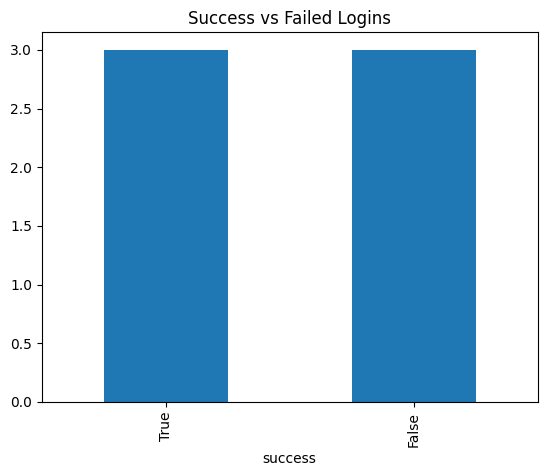

In [182]:
df['success'].value_counts().plot(kind='bar')
plt.title("Success vs Failed Logins")
plt.show()

In [183]:
failed = df[df['success'] == False]

failed['user_id'].value_counts().head(5)

user_id
mary    2
john    1
Name: count, dtype: int64

In [184]:
df.groupby('country')['ip_address'].nunique()

country
Kenya       1
Tanzania    1
Uganda      1
Name: ip_address, dtype: int64

In [185]:
df.groupby('hour').size()

hour
8    6
dtype: int64

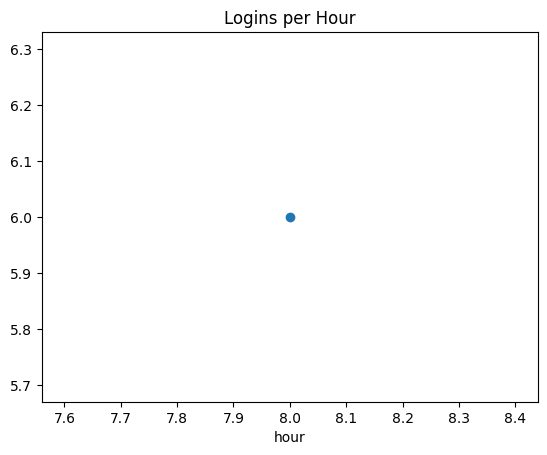

In [186]:
df.groupby('hour').size().plot(kind='line', marker='o')
plt.title("Logins per Hour")
plt.show()

In [187]:
df[df['success'] == False].groupby('hour').size().idxmax()

np.int32(8)

In [188]:
df = df.sort_values(by=['user_id', 'timestamp'])

In [189]:
df['prev_success'] = df['success'].shift(1)
df['prev_time'] = df['timestamp'].shift(1)

In [190]:
df['time_diff'] = (df['timestamp'] - df['prev_time']).dt.total_seconds() / 60

In [191]:
suspicious = df[
    (df['prev_success'] == False) &
    (df['success'] == True) &
    (df['time_diff'] <= 5)
]

In [192]:
failed_counts = df[df['success'] == False].groupby('user_id').size()
high_failed = failed_counts[failed_counts > 10].index

In [193]:
flagged = suspicious[suspicious['user_id'].isin(high_failed)]

flagged['user_id'].unique()

<StringArray>
[]
Length: 0, dtype: str

### Summary

1. There are many failed login attempts.
2. Some users show repeated failures.
3. Certain hours have high activity.
4. Multiple IPs across countries were used.
5. Suspicious login patterns were detected.

### Recommendations

1. Use multi-factor authentication.
2. Block users after many failed attempts.